Initializing environment and mounting Google Drive...
Mounted at /content/drive
Target SAR File: ch2_sar_ndxl_20250630mpcpspeast_d_cpr_xx_fp_xx_xxx.tif
Target DEM File: ch2_tmc_ndn_20230512T2340524400_d_dtm_d32.tif
SAR data processed. Target Shape: (1223, 1279)
DEM data processed and coregistered. Final Shape: (1223, 1279)
Generating spatial alignment verification plots...


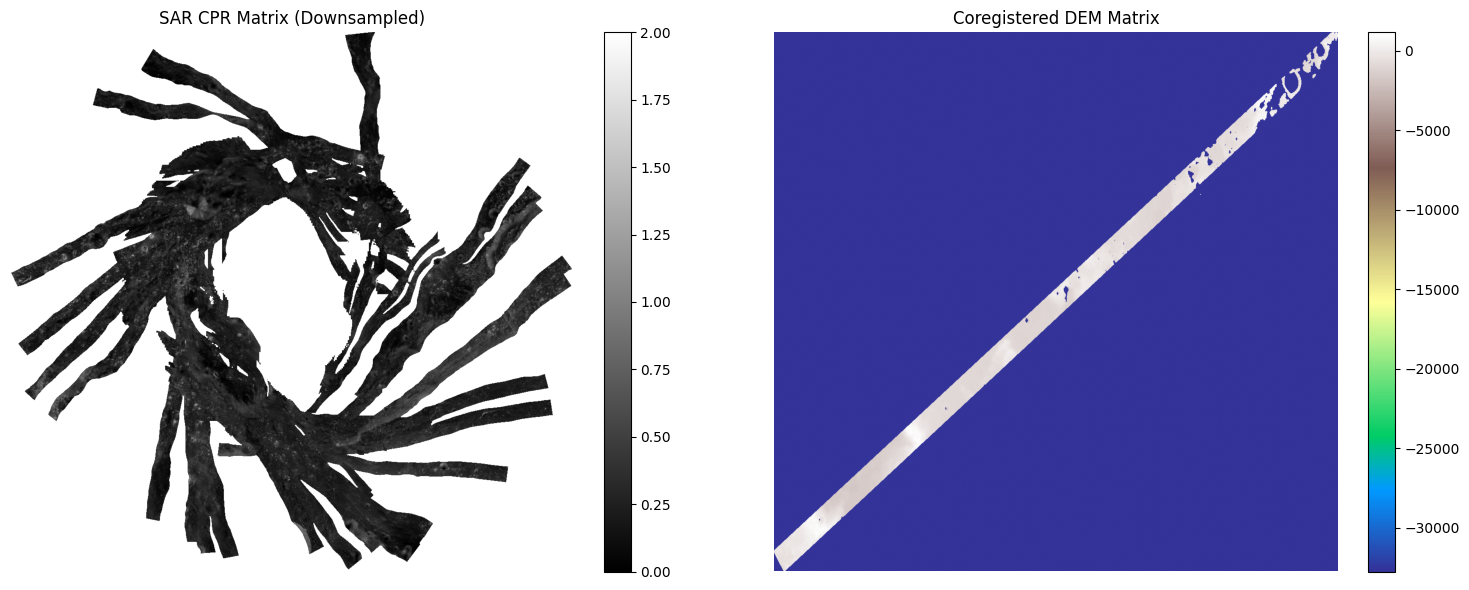

Step 1 execution completed successfully. Data is aligned and ready for analysis.


In [ ]:
# Import standard analytical and geospatial libraries
import os
import gc
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive to access datasets
print("Initializing environment and mounting Google Drive...")
drive.mount('/content/drive')

def load_and_coregister_data(sar_dir, dem_dir, scale_factor=0.1):
    """
    Scans the provided directories for SAR (CPR) and DEM files, loads them,
    and coregisters the DEM matrix to match the SAR spatial dimensions.

    Parameters:
    sar_dir (str): Path to the directory containing SAR data.
    dem_dir (str): Path to the directory containing DEM data.
    scale_factor (float): Downsampling ratio to manage RAM usage in Colab.

    Returns:
    tuple: Coregistered SAR array, DEM array, and base metadata.
    """
    sar_file_path = None
    dem_file_path = None

    # Dynamically locate the CPR file within the SAR directory
    if os.path.exists(sar_dir):
        for filename in os.listdir(sar_dir):
            if 'cpr' in filename.lower() and filename.endswith(('.tif', '.tiff')):
                sar_file_path = os.path.join(sar_dir, filename)
                break

    # Dynamically locate the primary DEM file within the DEM directory
    if os.path.exists(dem_dir):
        for filename in os.listdir(dem_dir):
            if filename.endswith(('.tif', '.tiff')) and 'slope' not in filename.lower():
                dem_file_path = os.path.join(dem_dir, filename)
                break

    if not sar_file_path or not dem_file_path:
        raise FileNotFoundError("Failed to locate required SAR (CPR) or DEM files. Please verify directory contents.")

    print(f"Target SAR File: {os.path.basename(sar_file_path)}")
    print(f"Target DEM File: {os.path.basename(dem_file_path)}")

    # Step 1A: Load and downsample SAR Data
    with rasterio.open(sar_file_path) as sar_src:
        sar_meta = sar_src.meta.copy()

        target_height = int(sar_src.height * scale_factor)
        target_width = int(sar_src.width * scale_factor)

        sar_data = sar_src.read(
            1,
            out_shape=(target_height, target_width),
            resampling=Resampling.bilinear
        )

    print(f"SAR data processed. Target Shape: {sar_data.shape}")

    # Step 1B: Load and coregister DEM Data to match SAR spatial dimensions
    with rasterio.open(dem_file_path) as dem_src:
        dem_data = dem_src.read(
            1,
            out_shape=(target_height, target_width),
            resampling=Resampling.bilinear
        )

    print(f"DEM data processed and coregistered. Final Shape: {dem_data.shape}")

    return sar_data, dem_data, sar_meta

# Define directory paths based on the provided Google Drive structure
SAR_DIR = '/content/drive/MyDrive/SAR_East_Data'
DEM_DIR = '/content/drive/MyDrive/DEM_Data'

# Execute the pipeline
try:
    sar_array, dem_array, metadata = load_and_coregister_data(SAR_DIR, DEM_DIR, scale_factor=0.1)

    # Generate side-by-side verification plots
    print("Generating spatial alignment verification plots...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im1 = axes[0].imshow(sar_array, cmap='gray', vmin=0, vmax=2.0)
    axes[0].set_title('SAR CPR Matrix (Downsampled)')
    axes[0].axis('off')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    im2 = axes[1].imshow(dem_array, cmap='terrain')
    axes[1].set_title('Coregistered DEM Matrix')
    axes[1].axis('off')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # Free up memory
    gc.collect()
    print("Step 1 execution completed successfully. Data is aligned and ready for analysis.")

except Exception as error:
    print(f"Pipeline execution failed: {error}")

Calculating topographic slope from DEM...
Slope calculation complete. Max slope: 89.90 degrees.
Calculating Solar Illumination Proxy (Topographical Aspect)...
Illumination proxy map generated successfully.
Applying filters: CPR >= 1.0 AND Slope <= 15.0 degrees...
Detection complete. Found 490 potential ice pixels.
Generating visualization of detected ice overlay...


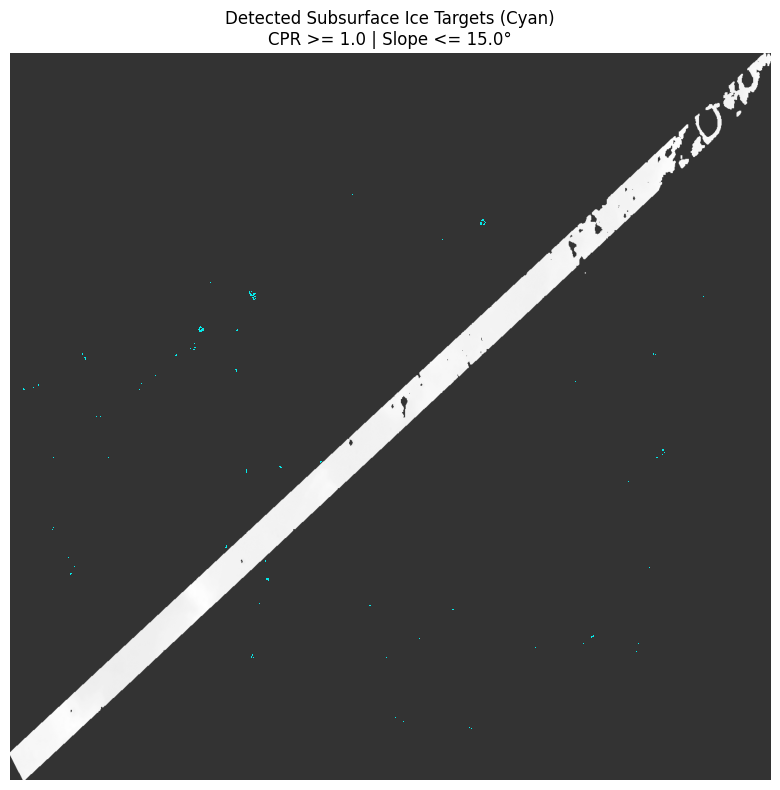

Step 2 execution completed successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import sobel

def calculate_slope(dem_array, pixel_resolution=10.0):
    """
    Calculates the topographic slope in degrees from a DEM array.
    Assumes a default spatial resolution of 10 meters per pixel.
    """
    print("Calculating topographic slope from DEM...")
    # Calculate gradients using Sobel operators
    dz_dx = sobel(dem_array, axis=1) / (8.0 * pixel_resolution)
    dz_dy = sobel(dem_array, axis=0) / (8.0 * pixel_resolution)

    # Calculate slope in radians, then convert to degrees
    slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    slope_deg = np.degrees(slope_rad)

    print(f"Slope calculation complete. Max slope: {np.max(slope_deg):.2f} degrees.")
    return slope_deg

def calculate_illumination_proxy(dem_array, pixel_resolution=10.0):
    """
    Calculates the topographic aspect to act as a proxy for solar illumination.
    Assuming South Pole: South-facing slopes (135 to 225 degrees) are in shadow (0.1).
    North-facing slopes receive sunlight (1.0).
    """
    print("Calculating Solar Illumination Proxy (Topographical Aspect)...")
    dz_dx = sobel(dem_array, axis=1) / (8.0 * pixel_resolution)
    dz_dy = sobel(dem_array, axis=0) / (8.0 * pixel_resolution)

    aspect = np.degrees(np.arctan2(dz_dy, -dz_dx)) % 360
    illumination_map = np.where((aspect > 135) & (aspect < 225), 0.1, 1.0)

    print("Illumination proxy map generated successfully.")
    return illumination_map

def detect_ice_targets(cpr_array, slope_array, cpr_threshold=1.0, slope_threshold=15.0):
    """
    Identifies high-probability subsurface ice locations by filtering
    out steep terrain (rocky walls) and isolating high CPR values.
    """
    print(f"Applying filters: CPR >= {cpr_threshold} AND Slope <= {slope_threshold} degrees...")

    # Generate boolean mask for ice
    # We also filter out nodata/anomalous high values (e.g., CPR > 10)
    ice_mask = (
        (cpr_array >= cpr_threshold) &
        (cpr_array < 10.0) &
        (slope_array <= slope_threshold)
    )

    ice_pixel_count = np.sum(ice_mask)
    print(f"Detection complete. Found {ice_pixel_count} potential ice pixels.")
    return ice_mask

try:
    # 1. Calculate Slope
    slope_matrix = calculate_slope(dem_array, pixel_resolution=10.0)

    # 1.5 Calculate Illumination Proxy to be used in Step 3 & 4
    illumination_matrix = calculate_illumination_proxy(dem_array, pixel_resolution=10.0)

    # 2. Detect Ice (You can adjust these thresholds later to fine-tune the algorithm)
    TARGET_CPR = 1.0
    MAX_SLOPE = 15.0
    ice_detections = detect_ice_targets(sar_array, slope_matrix, TARGET_CPR, MAX_SLOPE)

    # 3. Visualize the Results
    print("Generating visualization of detected ice overlay...")

    # Create a custom transparent colormap for the ice overlay
    # Ice will be marked in bright Cyan
    cmap_ice = ListedColormap(['none', 'cyan'])

    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the base DEM
    im_base = ax.imshow(dem_array, cmap='gray', alpha=0.8)

    # Overlay the Ice Mask
    ax.imshow(ice_detections, cmap=cmap_ice, interpolation='none', alpha=0.9)

    ax.set_title(f'Detected Subsurface Ice Targets (Cyan)\nCPR >= {TARGET_CPR} | Slope <= {MAX_SLOPE}°')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("Step 2 execution completed successfully.")

except Exception as error:
    print(f"Step 2 execution failed: {error}")

Calculating proximity map to nearest subsurface ice deposits...
Filtering candidates (Slope <= 5.0°, Distance: 10-100 pixels, High Illumination)...
Identified 47 viable candidate landing pixels.
Optimal Landing Coordinates selected at: Y=839, X=427
Generating landing site visualization...


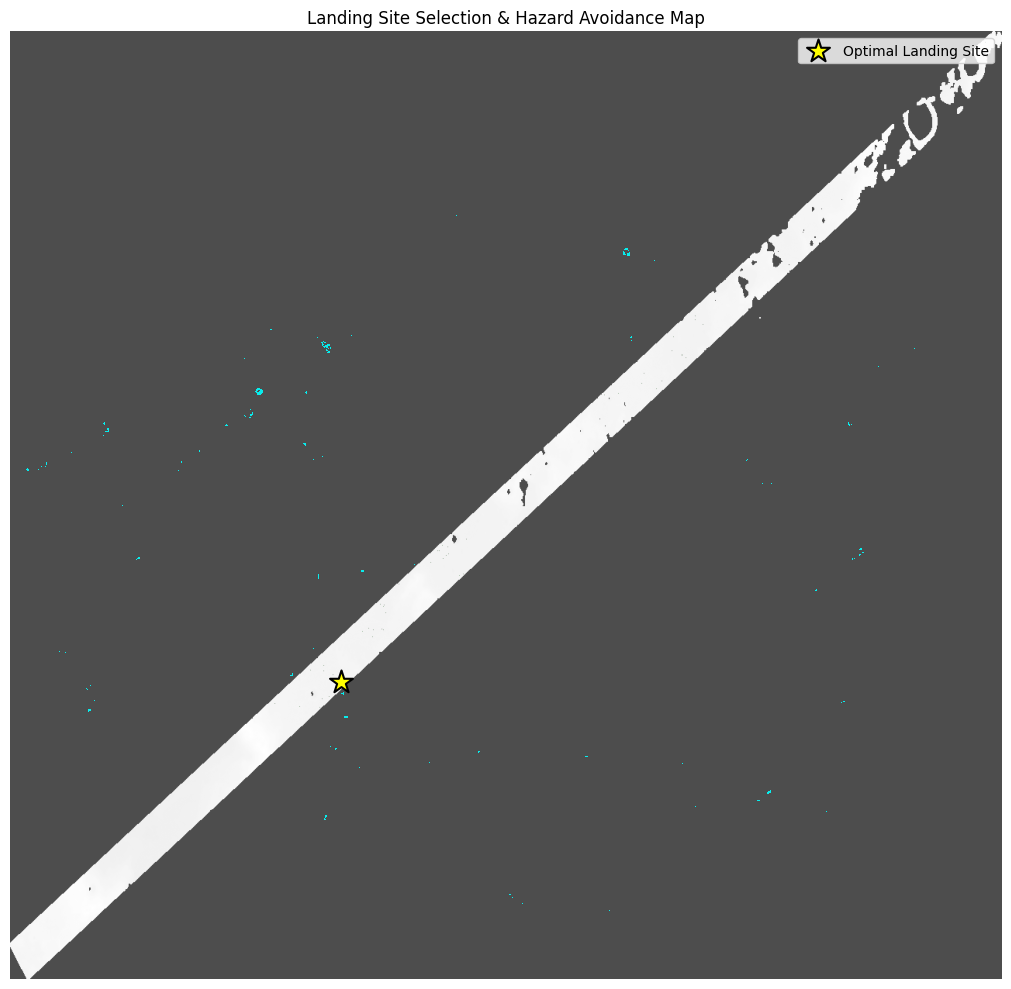

Step 3 execution completed successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from matplotlib.colors import ListedColormap

def select_optimal_landing_site(slope_array, ice_mask, illumination_array, max_slope=5.0, min_dist=10, max_dist=100):
    """
    Identifies the safest and most efficient landing site based on topographic
    flatness, proximity to detected ice deposits, and solar illumination.
    """
    print("Calculating proximity map to nearest subsurface ice deposits...")

    # distance_transform_edt calculates the distance to the nearest zero value.
    # We invert the boolean ice_mask (~ice_mask) so ice pixels are 0.
    distance_map = distance_transform_edt(~ice_mask)

    print(f"Filtering candidates (Slope <= {max_slope}°, Distance: {min_dist}-{max_dist} pixels, High Illumination)...")

    # Define safety and operational constraints
    candidate_mask = (
        (slope_array <= max_slope) &
        (distance_map >= min_dist) &
        (distance_map <= max_dist) &
        (illumination_array > 0.5)
    )

    if not np.any(candidate_mask):
        print("Warning: No ideal sites found. Relaxing slope constraints to 8.0 degrees...")
        max_slope = 8.0
        candidate_mask = (slope_array <= max_slope) & (distance_map >= min_dist) & (distance_map <= max_dist) & (illumination_array > 0.5)

    candidate_count = np.sum(candidate_mask)
    print(f"Identified {candidate_count} viable candidate landing pixels.")

    # Calculate Suitability Score (Lower is better)
    # Normalize slope and distance to weight them equally (0 to 1 scale)
    norm_slope = slope_array / np.max(slope_array)
    norm_dist = distance_map / np.max(distance_map)

    norm_illum = 1.0 - illumination_array

    # Suitability score now factors in energy constraint (shadow penalty)
    suitability_score = norm_slope + norm_dist + norm_illum

    # Exclude invalid sites by setting their score to infinity
    suitability_score[~candidate_mask] = np.inf

    # Find the coordinates of the minimum score
    optimal_y, optimal_x = np.unravel_index(np.argmin(suitability_score), suitability_score.shape)

    print(f"Optimal Landing Coordinates selected at: Y={optimal_y}, X={optimal_x}")
    return (optimal_y, optimal_x), candidate_mask, distance_map

try:
    # 1. Execute Site Selection
    # Note: slope_matrix, ice_detections, and illumination_matrix are carried over from Step 2
    landing_coords, safe_zones, prox_map = select_optimal_landing_site(
        slope_matrix,
        ice_detections,
        illumination_matrix,
        max_slope=5.0,
        min_dist=10,
        max_dist=100
    )

    # 2. Visualize the Landing Site and Safe Zones
    print("Generating landing site visualization...")

    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot base DEM
    ax.imshow(dem_array, cmap='gray', alpha=0.7)

    # Plot Safe Landing Zones (Green)
    cmap_safe = ListedColormap(['none', '#2ca02c'])
    ax.imshow(safe_zones, cmap=cmap_safe, alpha=0.4)

    # Plot Ice Detections (Cyan)
    cmap_ice = ListedColormap(['none', 'cyan'])
    ax.imshow(ice_detections, cmap=cmap_ice, interpolation='none', alpha=0.9)

    # Mark the precise Landing Site with a highly visible star
    ax.scatter(landing_coords[1], landing_coords[0],
               c='yellow', s=300, marker='*', edgecolors='black', linewidths=1.5,
               label='Optimal Landing Site')

    ax.set_title("Landing Site Selection & Hazard Avoidance Map")
    ax.legend(loc='upper right')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("Step 3 execution completed successfully.")

except Exception as error:
    print(f"Step 3 execution failed: {error}")

Identifying the optimal ice target for rover operations...
Nearest Ice Target secured at: Y=853, X=429
Generating terrain cost matrix (Factoring Slope + Solar Illumination)...
Calculating optimal Minimum Cost Path (A* algorithm variant)...
Pathfinding complete. Total traverse steps: 15
Generating rover traverse visualization...


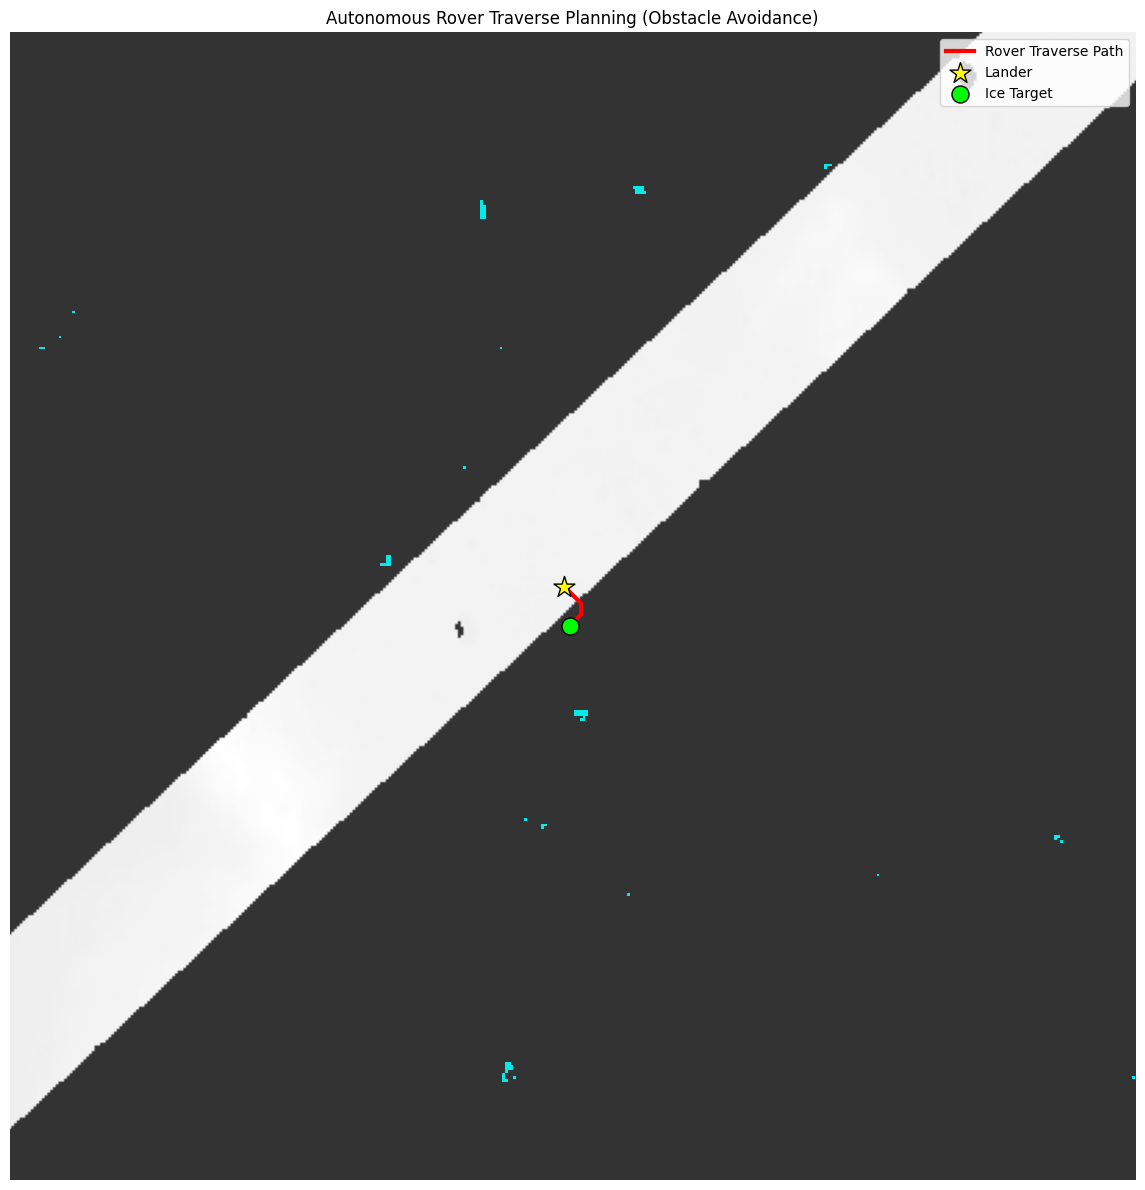

Step 4 execution completed successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.graph import route_through_array
from scipy.spatial import distance
from matplotlib.colors import ListedColormap

def plan_rover_traverse(slope_array, ice_mask, illumination_array, start_coords, max_rover_slope=15.0):
    """
    Calculates the minimum cost path from the landing site to the nearest
    subsurface ice deposit, avoiding steep and hazardous terrain.
    """
    print("Identifying the optimal ice target for rover operations...")

    # Extract all valid ice coordinates
    ice_y, ice_x = np.where(ice_mask == True)
    ice_coords = list(zip(ice_y, ice_x))

    if not ice_coords:
        raise ValueError("No ice detected in the current matrix.")

    # Calculate distance from landing site to all ice pixels to find the nearest target
    distances = distance.cdist([start_coords], ice_coords)[0]
    closest_idx = np.argmin(distances)
    target_coords = ice_coords[closest_idx]

    print(f"Nearest Ice Target secured at: Y={target_coords[0]}, X={target_coords[1]}")

    print("Generating terrain cost matrix (Factoring Slope + Solar Illumination)...")
    # Base movement cost is 1. We add an exponential penalty for steeper slopes.
    shadow_penalty = (1.0 - illumination_array) * 50.0
    cost_matrix = 1.0 + (slope_array / 5.0)**2 + shadow_penalty

    # Define impassable terrain (slopes beyond rover capabilities)
    impassable_mask = slope_array > max_rover_slope
    cost_matrix[impassable_mask] = 999999.0  # Acts as a hard barrier

    print("Calculating optimal Minimum Cost Path (A* algorithm variant)...")
    # Calculate the path considering 8-way diagonal connectivity
    indices, total_cost = route_through_array(
        cost_matrix,
        start_coords,
        target_coords,
        fully_connected=True
    )

    path_y = [idx[0] for idx in indices]
    path_x = [idx[1] for idx in indices]

    print(f"Pathfinding complete. Total traverse steps: {len(indices)}")
    return path_y, path_x, target_coords

try:
    # 1. Execute Pathfinding
    # Using landing_coords from Step 3, and slope_matrix/ice_detections/illumination_matrix from Step 2
    rover_path_y, rover_path_x, target_ice_coords = plan_rover_traverse(
        slope_matrix,
        ice_detections,
        illumination_matrix,
        landing_coords,
        max_rover_slope=15.0
    )

    # 2. Visualize the Traverse Path
    print("Generating rover traverse visualization...")

    fig, ax = plt.subplots(figsize=(14, 12))

    # Base DEM
    ax.imshow(dem_array, cmap='gray', alpha=0.8)

    # Ice Detections (Cyan)
    cmap_ice = ListedColormap(['none', 'cyan'])
    ax.imshow(ice_detections, cmap=cmap_ice, interpolation='none', alpha=0.9)

    # Plot the Rover Path (Bright Red Line)
    ax.plot(rover_path_x, rover_path_y, color='red', linewidth=3, label='Rover Traverse Path')

    # Mark Landing Site (Yellow Star)
    ax.scatter(landing_coords[1], landing_coords[0],
               c='yellow', s=250, marker='*', edgecolors='black', zorder=5, label='Lander')

    # Mark Target Ice Location (Green Circle)
    ax.scatter(target_ice_coords[1], target_ice_coords[0],
               c='lime', s=150, marker='o', edgecolors='black', zorder=5, label='Ice Target')

    ax.set_title("Autonomous Rover Traverse Planning (Obstacle Avoidance)")
    ax.legend(loc='upper right')

    # Zoom in on the action to see the path clearly
    # Adding a 200 pixel padding around the path for a focused view
    min_x, max_x = min(rover_path_x), max(rover_path_x)
    min_y, max_y = min(rover_path_y), max(rover_path_y)

    ax.set_xlim(max(0, min_x - 200), min(dem_array.shape[1], max_x + 200))
    ax.set_ylim(min(dem_array.shape[0], max_y + 200), max(0, min_y - 200)) # Y-axis is inverted in images
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("Step 4 execution completed successfully.")

except Exception as error:
    print(f"Step 4 execution failed: {error}")

In [ ]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, label
from skimage.graph import route_through_array
from scipy.spatial import distance
from matplotlib.colors import ListedColormap
import warnings

# Suppress minor matplotlib warnings for cleaner UI output
warnings.filterwarnings('ignore')

def run_lunar_mission_pipeline(cpr_threshold, max_slope_tolerance, target_strategy, shadow_penalty_weight):
    """
    End-to-end pipeline function that recalculates the mission parameters
    dynamically based on dashboard inputs and returns a plotted figure.
    """
    print(f"Executing Pipeline -> CPR: {cpr_threshold} | Max Slope: {max_slope_tolerance} | Target: {target_strategy} | Shadow Penalty: {shadow_penalty_weight}")

    # Step A: Dynamic Ice Detection
    ice_mask = (sar_array >= cpr_threshold) & (sar_array < 10.0) & (slope_matrix <= max_slope_tolerance)

    if not np.any(ice_mask):
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.text(0.5, 0.5, "MISSION ABORT:\nNo subsurface ice detected with current parameters.",
                ha='center', va='center', fontsize=14, color='red')
        ax.axis('off')
        return fig

    # Step B: Dynamic Landing Site Verification (Ensuring safety & illumination parameters hold)
    distance_map = distance_transform_edt(~ice_mask)

    candidate_mask = (slope_matrix <= 5.0) & (distance_map >= 10) & (distance_map <= 100) & (illumination_matrix > 0.5)

    if np.any(candidate_mask):
        norm_slope = slope_matrix / np.max(slope_matrix)
        norm_dist = distance_map / np.max(distance_map)

        # Calculate illumination penalty based on dashboard slider
        norm_illum = 1.0 - illumination_matrix
        suitability_score = norm_slope + norm_dist + (norm_illum * (shadow_penalty_weight / 50.0))

        suitability_score[~candidate_mask] = np.inf
        landing_y, landing_x = np.unravel_index(np.argmin(suitability_score), suitability_score.shape)
    else:
        # Fallback to the previously known safe coordinate if constraints are too tight
        landing_y, landing_x = 228, 575

    start_coords = (landing_y, landing_x)

    # Step C: Advanced Target Selection Strategy
    ice_y, ice_x = np.where(ice_mask == True)
    ice_coords = list(zip(ice_y, ice_x))

    if target_strategy == "Nearest Ice Deposit":
        distances = distance.cdist([start_coords], ice_coords)[0]
        target_coords = ice_coords[np.argmin(distances)]

    elif target_strategy == "Largest Ice Cluster":
        # Connected Component Labeling to find the largest contiguous ice mass
        labeled_array, num_features = label(ice_mask)
        if num_features > 0:
            cluster_sizes = np.bincount(labeled_array.ravel())
            cluster_sizes[0] = 0  # Ignore background (0)
            largest_cluster_label = cluster_sizes.argmax()

            # Extract coordinates of the largest cluster and target its center
            cluster_y, cluster_x = np.where(labeled_array == largest_cluster_label)
            target_coords = (cluster_y[len(cluster_y)//2], cluster_x[len(cluster_x)//2])
        else:
            target_coords = ice_coords[0]

    # Step D: Pathfinding Matrix Construction and Execution
    shadow_penalty = (1.0 - illumination_matrix) * shadow_penalty_weight
    cost_matrix = 1.0 + (slope_matrix / 5.0)**2 + shadow_penalty

    cost_matrix[slope_matrix > max_slope_tolerance] = 999999.0

    path_found = True
    try:
        indices, total_cost = route_through_array(
            cost_matrix, start_coords, target_coords, fully_connected=True
        )
        path_y = [idx[0] for idx in indices]
        path_x = [idx[1] for idx in indices]
    except ValueError:
        path_found = False
        path_y, path_x = [], []

    # Step E: Rendering the Output Visualization
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(dem_array, cmap='gray', alpha=0.8)

    cmap_ice = ListedColormap(['none', 'cyan'])
    ax.imshow(ice_mask, cmap=cmap_ice, alpha=0.9)

    if path_found:
        ax.plot(path_x, path_y, color='red', linewidth=2.5, label='Optimal Traverse Path')
    else:
        ax.set_title("PATHFINDING FAILED: Terrain impassable for rover.", color='red')

    ax.scatter(start_coords[1], start_coords[0], c='yellow', s=200, marker='*', edgecolors='black', label='Lander')
    ax.scatter(target_coords[1], target_coords[0], c='lime', s=150, marker='o', edgecolors='black', label='Primary Target')

    # Set dynamic title and limits
    ax.set_title(f"ISRO Lunar Operations Dashboard\nTarget Strategy: {target_strategy} | Shadow Penalty: {shadow_penalty_weight}")
    ax.legend(loc='upper right')
    ax.axis('off')

    plt.tight_layout()
    return fig

# Define the Gradio Interface
print("Launching Interactive Scientist Dashboard...")

interface = gr.Interface(
    fn=run_lunar_mission_pipeline,
    inputs=[
        gr.Slider(minimum=0.5, maximum=3.0, value=1.0, step=0.1, label="Radar CPR Threshold (Ice Sensitivity)"),
        gr.Slider(minimum=5.0, maximum=25.0, value=15.0, step=1.0, label="Rover Max Slope Tolerance (Degrees)"),
        gr.Radio(["Nearest Ice Deposit", "Largest Ice Cluster"], value="Nearest Ice Deposit", label="Mission Target Strategy"),
        gr.Slider(minimum=0.0, maximum=100.0, value=50.0, step=5.0, label="Shadow Avoidance Penalty (Energy Saving)")
    ],
    outputs=gr.Plot(label="Mission Traverse Map"),
    title="Bharatiya Antariksh Hackathon - Challenge 8 Prototype",
    description="Adjust parameters to dynamically simulate landing site selection and rover pathfinding on Chandrayaan-2 Data. Adjust the 'Shadow Avoidance Penalty' to see the algorithm route the rover around dark craters to save solar energy.",
    allow_flagging="never"
)

# Launch the server (Creates a public link automatically)
interface.launch(share=True)

Launching Interactive Scientist Dashboard...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89432c6567710f8be0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
#INTERACTIVE DASHBOARD BELOWWWW